In [ ]:
# 리스트에서 텐서 만들기 

import torch
import numpy as np

data=[[1,2],[3,4]]
x_data=torch.tensor(data)

print(x_data.shape, x_data.dtype, x_data.device)
print(x_data)

torch.Size([2, 2]) torch.int64 cpu
tensor([[1, 2],
        [3, 4]])


In [ ]:
# 배열에서 텐서 만들기

# import torch
# import numpy as np

data=[[1,2],[3,4]]
x_np = np.array(data)

x_data=torch.tensor(x_np, dtype=torch.int16)
print(x_data.shape, x_data.dtype)
print(x_data)

x_data=torch.from_numpy(x_np)
print(x_data.shape, x_data.dtype)
print(x_data)

x_data=torch.as_tensor(x_np, dtype=torch.float)
print(x_data.shape, x_data.dtype)
print(x_data)

torch.Size([2, 2]) torch.int16
tensor([[1, 2],
        [3, 4]], dtype=torch.int16)
torch.Size([2, 2]) torch.int64
tensor([[1, 2],
        [3, 4]])
torch.Size([2, 2]) torch.float32
tensor([[1., 2.],
        [3., 4.]])


In [3]:
shape=(2,3,)
ones_tensor=torch.ones(shape)
zeros_tensor=torch.zeros(shape)
rand_tensor=torch.rand(shape)

print(ones_tensor)
print(zeros_tensor)
print(rand_tensor)

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[0.6685, 0.5612, 0.8013],
        [0.1940, 0.2952, 0.5667]])


In [4]:
data=[[1,2],[3,4]]
x_np=np.array(data)
x_data=torch.as_tensor(x_np, dtype=torch.float)

x_ones=torch.ones_like(x_data)
x_zeros=torch.zeros_like(x_data)
x_rand=torch.rand_like(x_data)

print(x_ones)
print(x_zeros)
print(x_rand)

tensor([[1., 1.],
        [1., 1.]])
tensor([[0., 0.],
        [0., 0.]])
tensor([[0.6043, 0.3649],
        [0.4160, 0.7432]])


In [5]:
# 기본 연산

a=torch.tensor([1,2,3])
b=torch.tensor([4,5,6])

c=a*b

print(c)
print(c.sum())
print(c.sum().item())
print(type(c.sum().item()))

tensor([ 4, 10, 18])
tensor(32)
32
<class 'int'>


In [6]:
# 슬라이싱

a=torch.tensor([1,2,3,4,5,6])

b1=a[0:3]
b2=a[3:6]

print(b1)
print(b2)

tensor([1, 2, 3])
tensor([4, 5, 6])


In [7]:
# torch.cat()

a=torch.tensor([[1,2,3],[4,5,6]])
b=torch.tensor([[7,8,9],[10,11,12]])

print("a shape:", a.shape)
print("b shape:", b.shape)

print("--------------")

t=torch.cat([a,b], dim=0)
print("t shape:", t.shape)
print(t)

print("--------------")

t=torch.cat([a,b], dim=1)
print("t shape:", t.shape)
print(t)



a shape: torch.Size([2, 3])
b shape: torch.Size([2, 3])
--------------
t shape: torch.Size([4, 3])
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
--------------
t shape: torch.Size([2, 6])
tensor([[ 1,  2,  3,  7,  8,  9],
        [ 4,  5,  6, 10, 11, 12]])


In [ ]:
# GPU

tensor=torch.rand(3,4)

if torch.cuda.is_available():
    tensor=tensor.to("cuda")

In [8]:
# 자동 미분

x_data=torch.tensor([0.5], requires_grad=True)
y=2.0 * x_data**5 + 1.0
y.backward()
x_data.grad.item() # 기울기

0.625

In [9]:
# 2차 곡선 미분

x_samples=[-1.0,-0.75,-0.5,0.0,0.5,0.75,1.0]
grad_y_list=[]

for x in x_samples:
    pass

    grad_y_list.append(x_data.grad.item())

print(grad_y_list)

[0.625, 0.625, 0.625, 0.625, 0.625, 0.625, 0.625]


  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------- -------------------------- 2.9/8.3 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 21.2 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 44.7 MB/s  0:00:00

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- ---

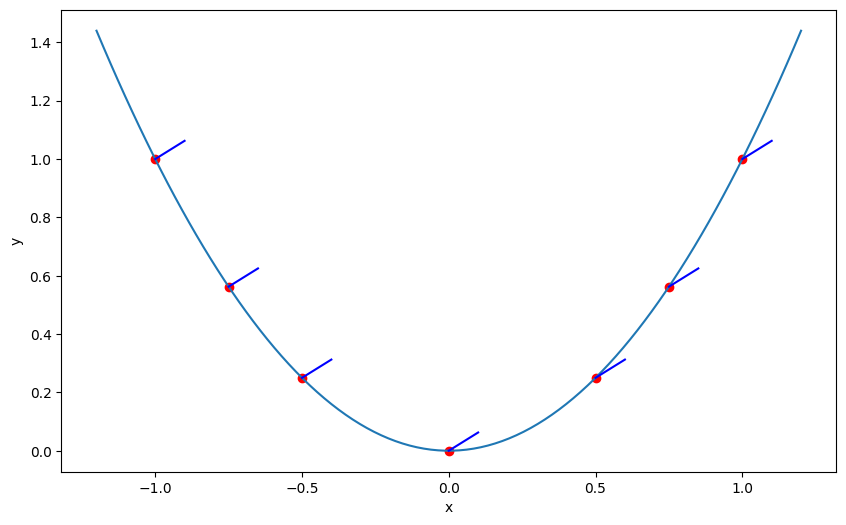

In [11]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.xlabel("x")
plt.ylabel("y")
plt.plot(np.linspace(-1.2,1.2,100), np.linspace(-1.2,1.2,100)**2)

plt.scatter(x_samples, [x**2 for x in x_samples], c="red")

dx=0.1
for x, grad_y in zip(x_samples, grad_y_list):
    if grad_y > 0.0:
        plt.plot([x,x+dx],[x**2,x**2+grad_y*dx], color='blue')
    elif grad_y < 0.0:
        plt.plot([x,x-dx],[x**2,x**2-grad_y*dx], color='blue')
    else:
        padd # grad_y == 0.0인 경우 그리지 않음